In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

import constants
from model_utils import *

from ast import literal_eval
from pathlib import Path

import matplotlib.cm as cm


import numpy as np

In [10]:
plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'test'
model_type = constants.Annotations
base_dir = Path.cwd().parent

In [11]:
target_columns = model_type.model_fields.keys()

reg_fields = get_regression_fields(model_type)
cl_fields = get_classification_fields(model_type)
mc_fields = get_multiple_choice_fields(model_type)
bc_fields = get_binary_classification_fields(model_type)
label_to_id_map = create_label_to_id_map(model_type)
mc_fields_estesi = []
for field in get_binary_classification_fields(constants.RectalCancerStagingData):
    if field not in bc_fields:
        mc_fields_estesi.append(field)

# Fields performance

In [12]:
##############
# Load metrics
##############

dfs = dict()

bl_most_frequent = pd.read_csv(base_dir / 'data' / 'metrics' / 'baseline_most_frequent_metrics.csv', index_col=[0, 1])

dfs['most_frequent'] = bl_most_frequent
bl_uniform = pd.read_csv(base_dir / 'data' / 'metrics' /  'baseline_uniform_metrics.csv', index_col=[0, 1])

dfs['uniform'] = bl_uniform
bl_stratified = pd.read_csv(base_dir / 'data' / 'metrics' /  'baseline_stratified_metrics.csv', index_col=[0, 1])

dfs['stratified'] = bl_stratified
dfs['mean'] = bl_uniform.loc[(reg_fields, ), :]

mistral_30 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_mistral_30.csv', index_col=[0, 1])
dfs['mistral_30'] = mistral_30

gpt_4_1_nano = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-nano.csv', index_col=[0, 1])
dfs['gpt_4_1_nano'] = gpt_4_1_nano

gpt_4_1_nano_tuned = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-nano-tuned.csv', index_col=[0, 1])
dfs['gpt_4_1_nano_tuned'] = gpt_4_1_nano_tuned

gpt_4_1_nano_tuned_oversampling = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-nano-tuned-oversampling.csv', index_col=[0, 1])
dfs['gpt_4_1_nano_tuned_oversampling'] = gpt_4_1_nano_tuned_oversampling

gpt_4_1_mini = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-mini.csv', index_col=[0, 1])
dfs['gpt_4_1_mini'] = gpt_4_1_mini

gpt_4_1 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1.csv', index_col=[0, 1])
dfs['gpt_4_1'] = gpt_4_1

gpt_4_1_tuned_oversampling = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-tuned-oversampling.csv', index_col=[0, 1])
dfs['gpt_4_1_tuned_oversampling'] = gpt_4_1_tuned_oversampling

gpt_5_nano = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-5-nano.csv', index_col=[0, 1])
dfs['gpt_5_nano'] = gpt_5_nano

gpt_5_2 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-5.2.csv', index_col=[0, 1])
dfs['gpt_5_2'] = gpt_5_2

mistral_large_3 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_mistral_large_3.csv', index_col=[0, 1])
dfs['mistral_large_3'] = mistral_large_3

opus_4_6 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_opus-4.6.csv', index_col=[0, 1])
dfs['opus_4_6'] = opus_4_6

In [13]:
def plot_grouped_barchart(fields: list[str], models: list[str], metric: str = 'f1_macro', res_dict=dfs) -> None:
    values: dict[str, list] = {
        model: round(res_dict[model].loc[(fields, SPLIT), metric], 2).to_list() for model in models
    }
    x = np.arange(len(fields))
    n_models = len(models)
    width = 0.8 / n_models
    
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, n_models)

    fig, ax = plt.subplots(layout='constrained', figsize=(14, 4))
    #fig, ax = plt.subplots(layout='constrained')
    
    for offset, (model, v) in zip(offsets, values.items()):
        rects = ax.bar(x + offset, v, width, label=model)
        ax.bar_label(rects, padding=3)
        
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by models - {SPLIT} set')
    ax.set_xticks(x, fields)
    #ax.legend(loc='upper left', ncols=3)
    ax.legend()
    #ax.set_ylim(0, 1)
    
    plt.show()

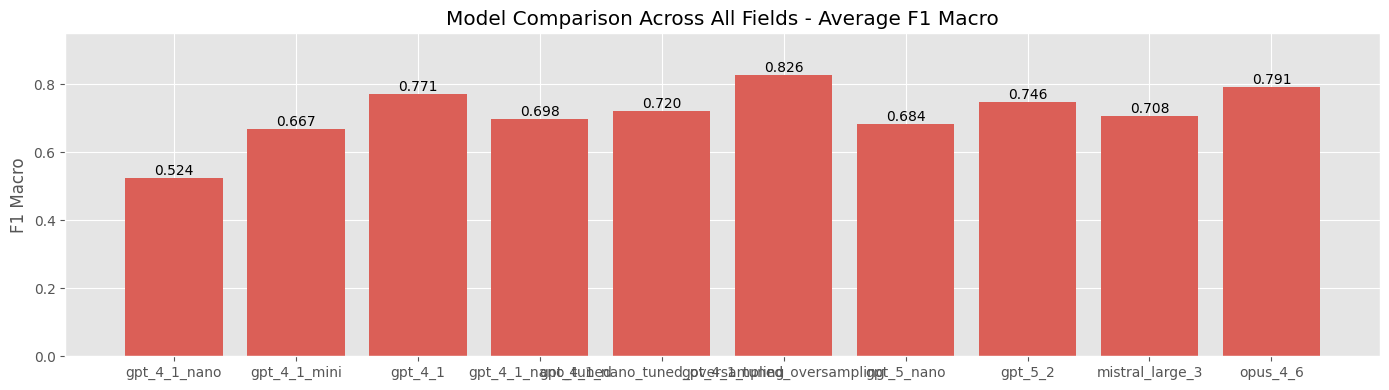

In [14]:
plot_models = [
    #'most_frequent',
    #'uniform',
    #'stratified',
    #'mistral_30',
    'gpt_4_1_nano',
    'gpt_4_1_mini',
    'gpt_4_1',
    'gpt_4_1_nano_tuned',
    'gpt_4_1_nano_tuned_oversampling',
    'gpt_4_1_tuned_oversampling',
    'gpt_5_nano',
    'gpt_5_2',
    'mistral_large_3',
    'opus_4_6'
]
fields = mc_fields + bc_fields + cl_fields
# Compute F1 means in a vectorized, readable way
f1_totals = [
    dfs[m].loc[(fields, SPLIT), "f1_macro"].mean()
    for m in plot_models
]
    
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(plot_models, f1_totals)

# Add value labels on top of each bar
for bar, value in zip(bars, f1_totals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
        )

ax.set_ylabel("F1 Macro")
ax.set_title("Model Comparison Across All Fields - Average F1 Macro")
ax.set_ylim(0, max(f1_totals) * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
s = dict()

for m in plot_models:
    d = dfs[m].loc[(fields, SPLIT), "f1_macro"]
    s[m] = d
    
f1_dataframe = pd.DataFrame(s).reset_index().drop(columns='split')

df_sharpe = f1_dataframe.drop(columns='field')
series_sharpe = df_sharpe.mean() / df_sharpe.std()

print(series_sharpe)

f1_dataframe = f1_dataframe.melt('field', var_name='model')
display(f1_dataframe.head())

gpt_4_1_nano                       2.409881
gpt_4_1_mini                       3.154871
gpt_4_1                            3.803763
gpt_4_1_nano_tuned                 3.755539
gpt_4_1_nano_tuned_oversampling    4.662145
gpt_4_1_tuned_oversampling         6.414603
gpt_5_nano                         3.596527
gpt_5_2                            3.436194
mistral_large_3                    3.586613
opus_4_6                           4.716663
dtype: float64


,field,model,value
0,posizione,gpt_4_1_nano,0.457341
1,infiltrazione_organi_dettagli,gpt_4_1_nano,0.485714
2,sedi_linfonodi,gpt_4_1_nano,0.498703
3,infiltrazione_sfinteri,gpt_4_1_nano,0.582185
4,infiltrazione_organi_extra,gpt_4_1_nano,0.792730


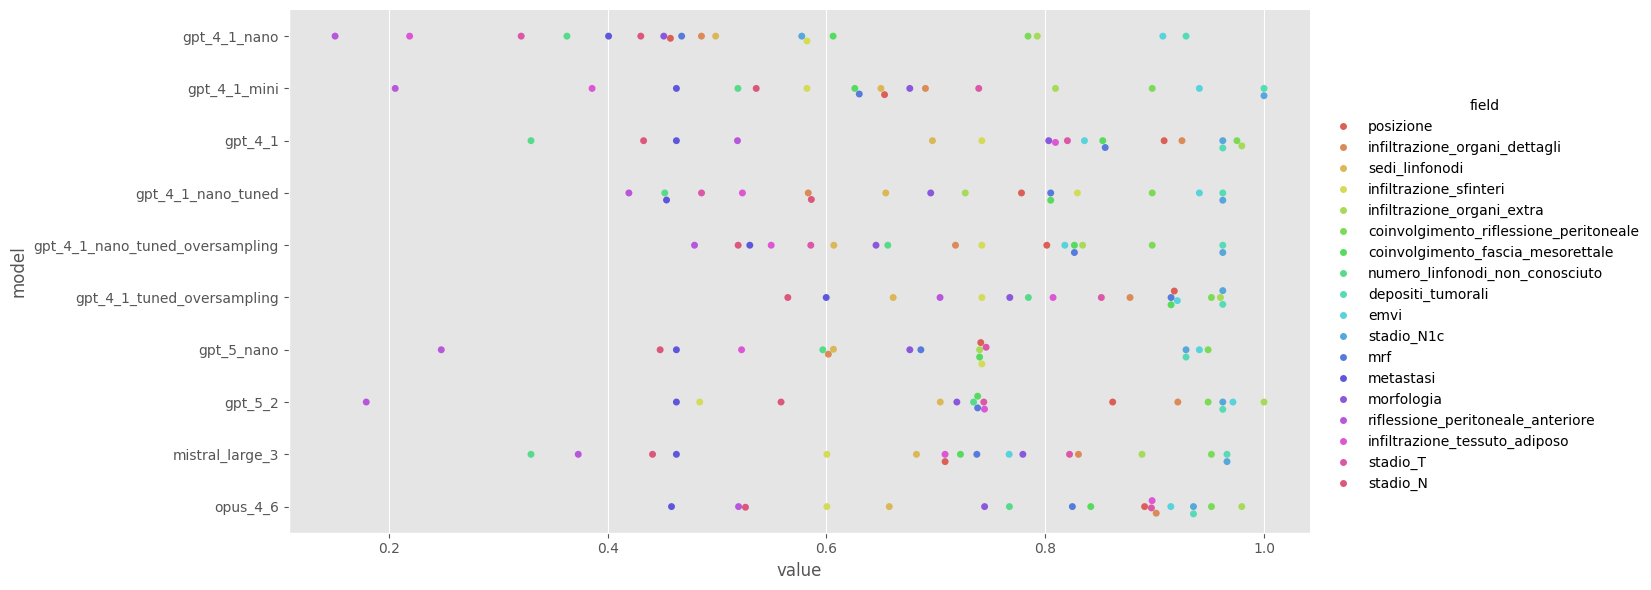

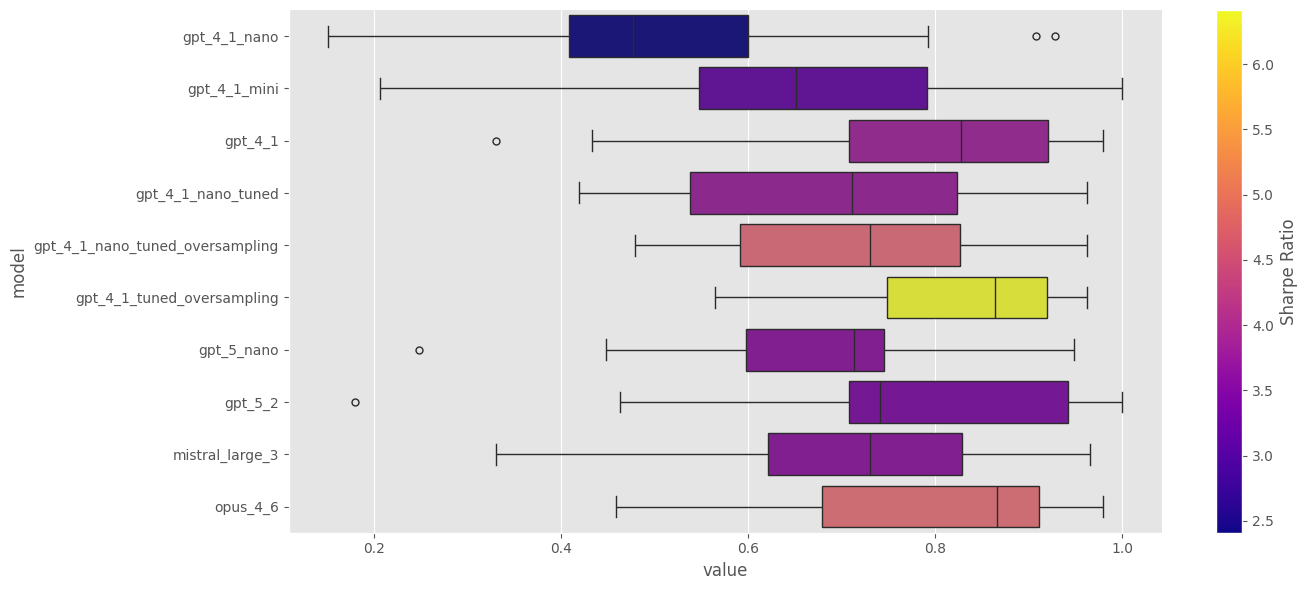

In [50]:
sns.catplot(data=f1_dataframe, y="model", x="value", kind='swarm', hue='field', height=6, aspect=21/9)


# Normalizziamo gli Sharpe tra 0 e 1
norm = (series_sharpe - series_sharpe.min()) / (series_sharpe.max() - series_sharpe.min())

# Scegli una colormap continua
cmap = sns.color_palette("plasma", as_cmap=True)
palette_sharpe = {model: cmap(norm[model]) for model in series_sharpe.index}
g = sns.catplot(data=f1_dataframe, x="value", y="model", height=6, aspect=21/9, kind='box',
            #order=series_sharpe.sort_values().index,
            palette=palette_sharpe, hue='model', legend=False)
fig = g.figure
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(series_sharpe.min(), series_sharpe.max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=g.axes, label="Sharpe Ratio")


plt.show()


## Multi-class fields

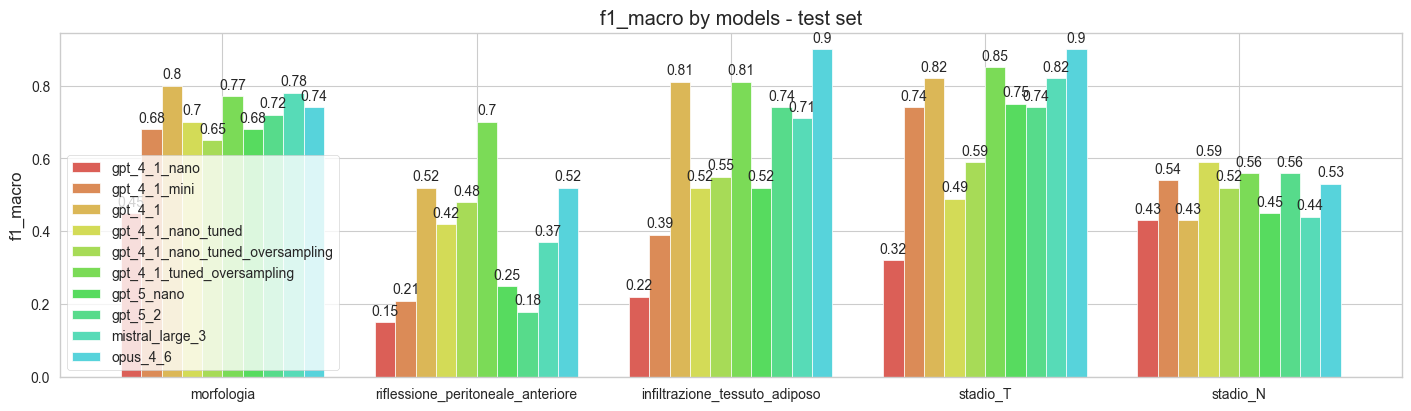

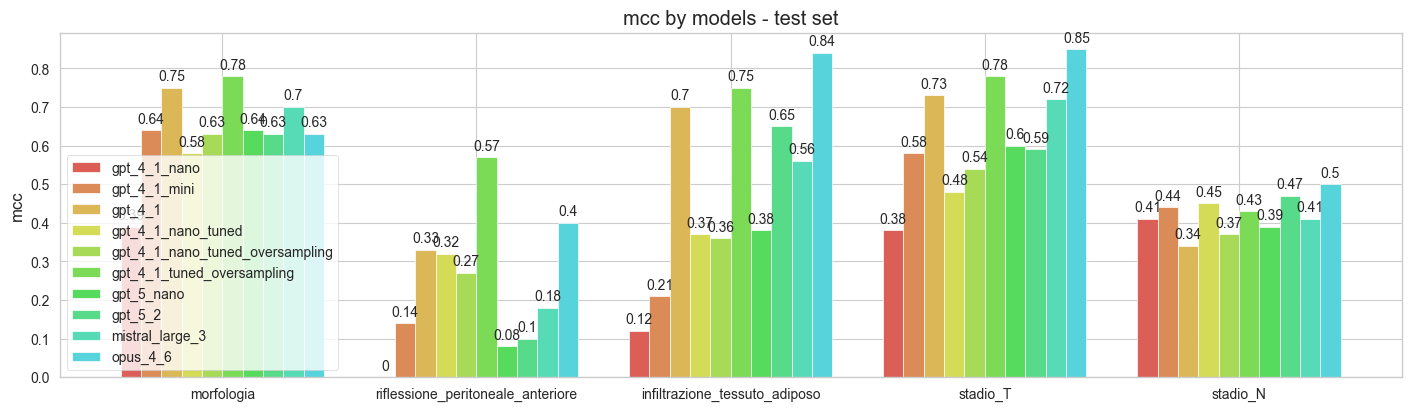

In [9]:
plot_fields = cl_fields

plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

## Binary fields

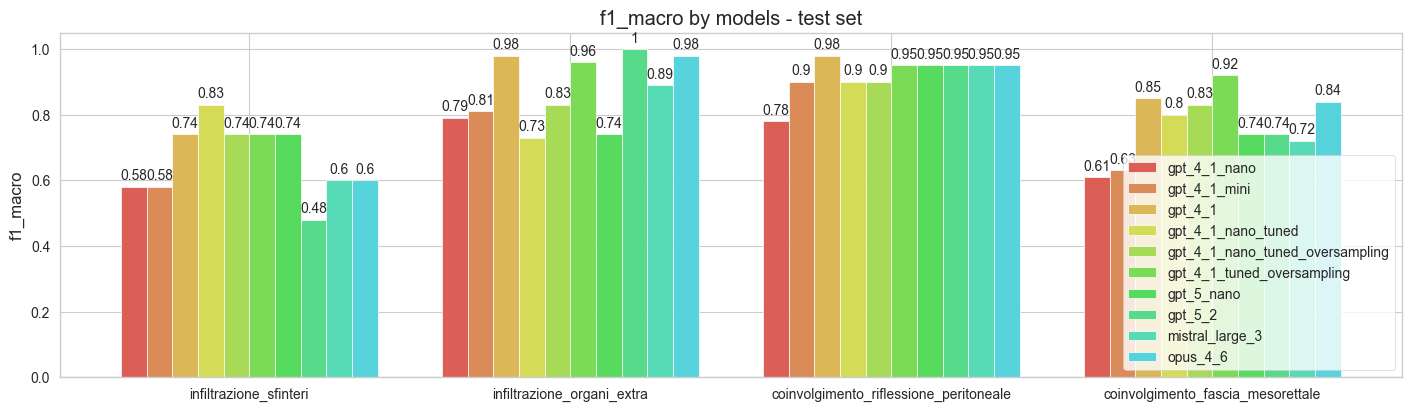

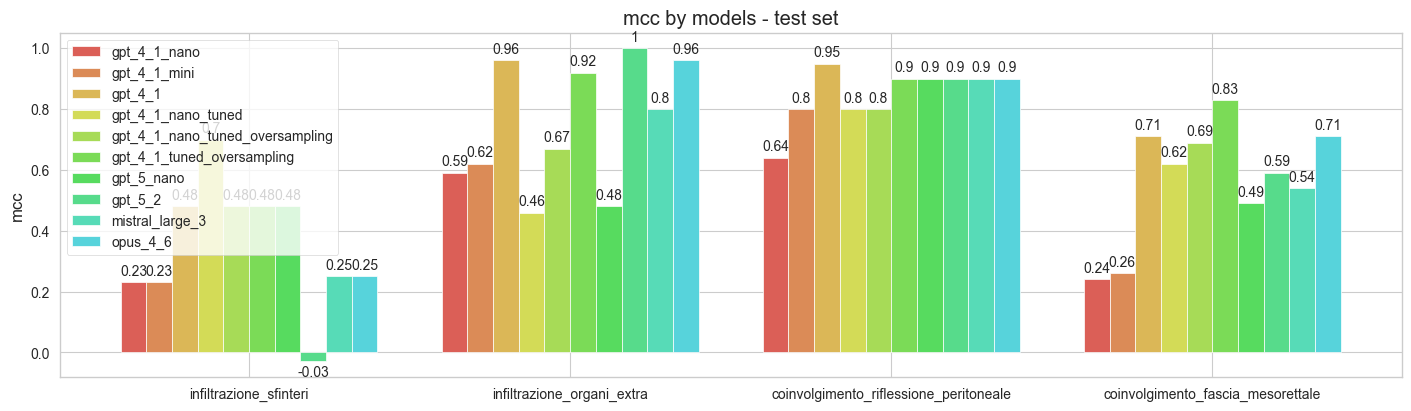

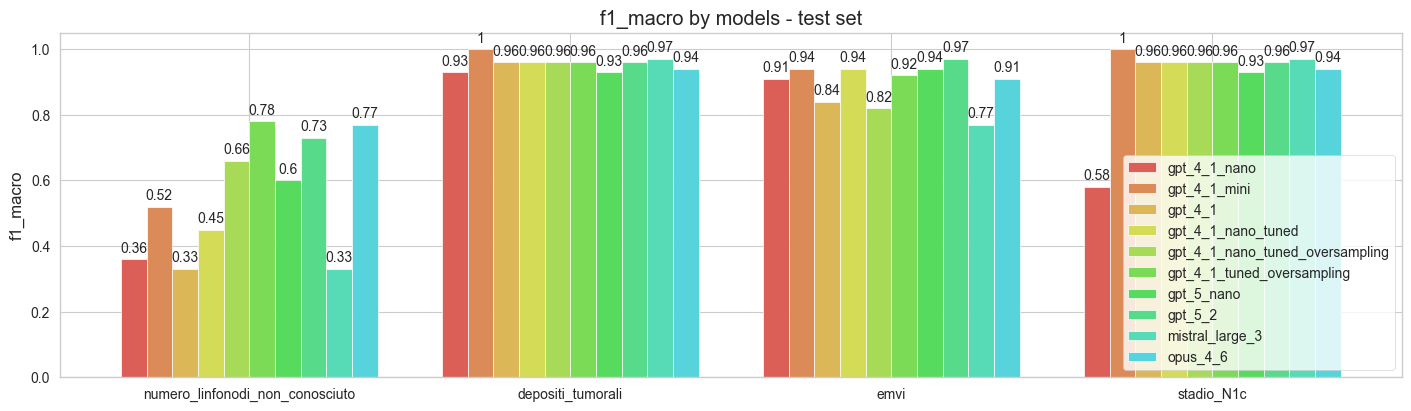

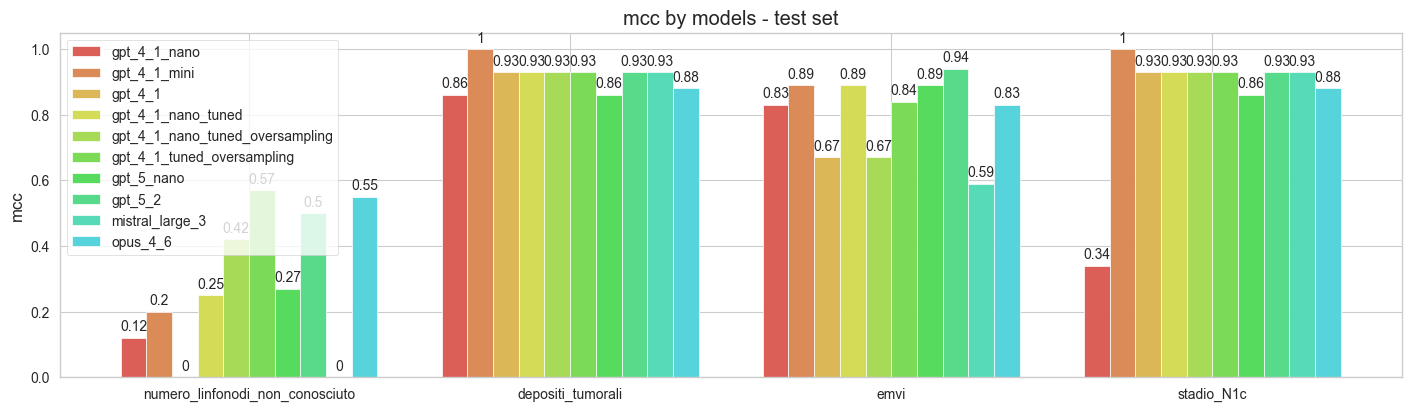

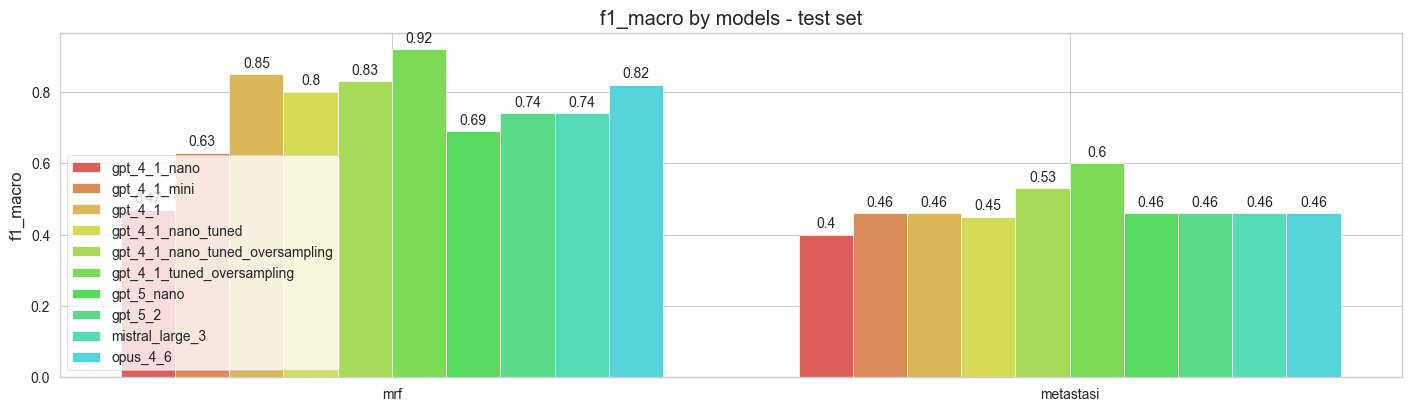

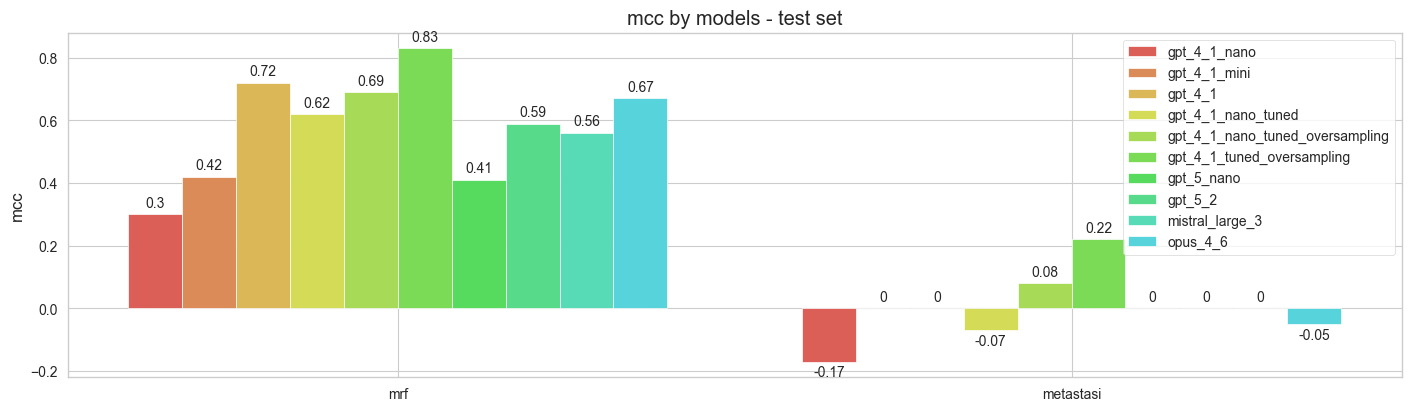

In [10]:
plot_fields = bc_fields[:4]
plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

plot_fields = bc_fields[4:8]
plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

plot_fields = bc_fields[8:]
plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

## Multilabel fields

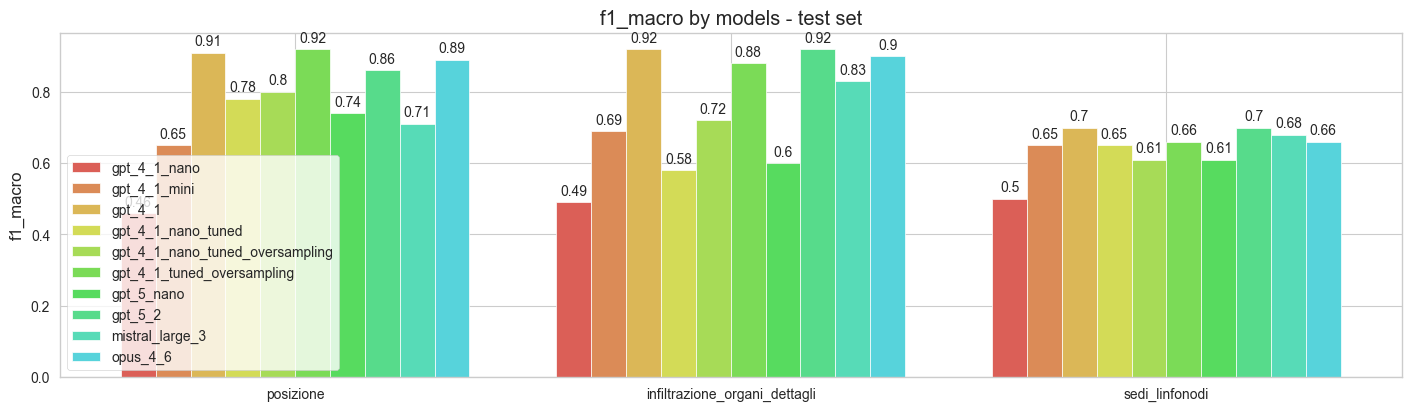

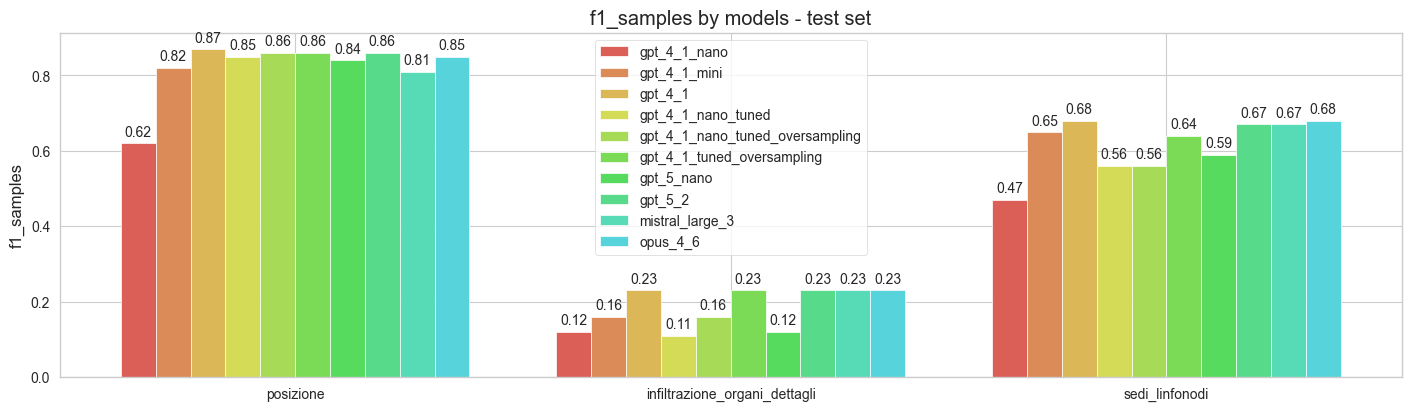

In [11]:
plot_fields = mc_fields

plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='f1_samples')

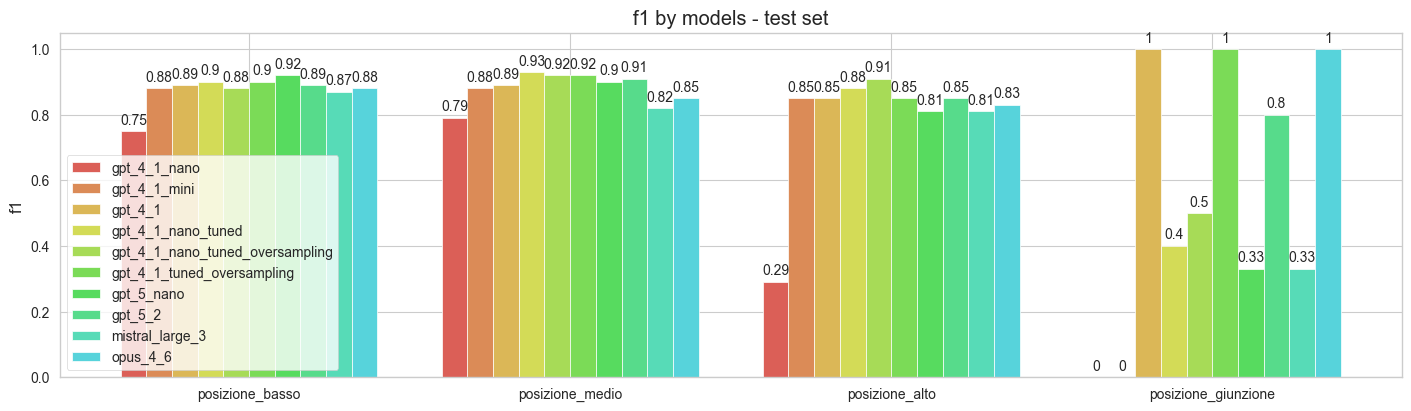

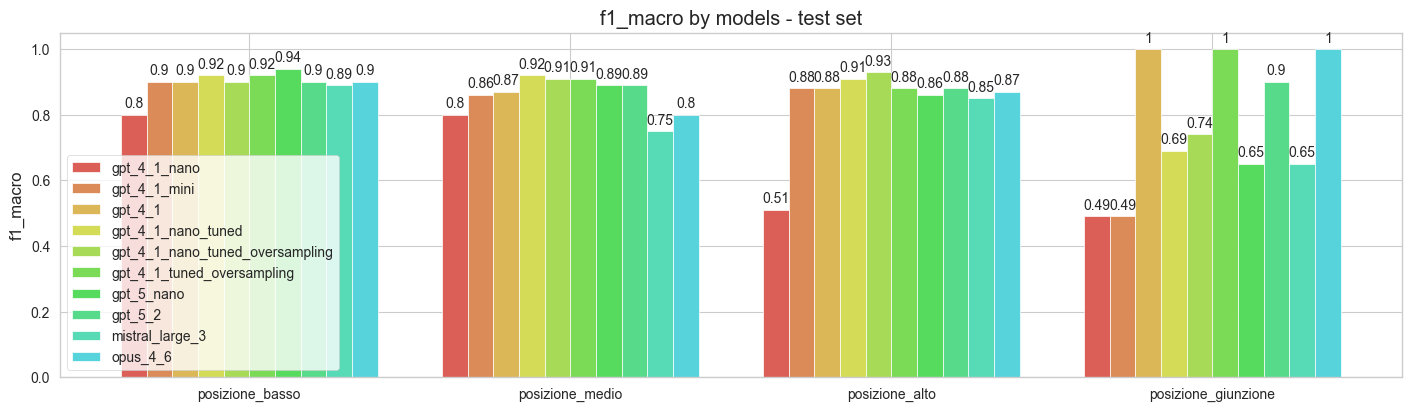

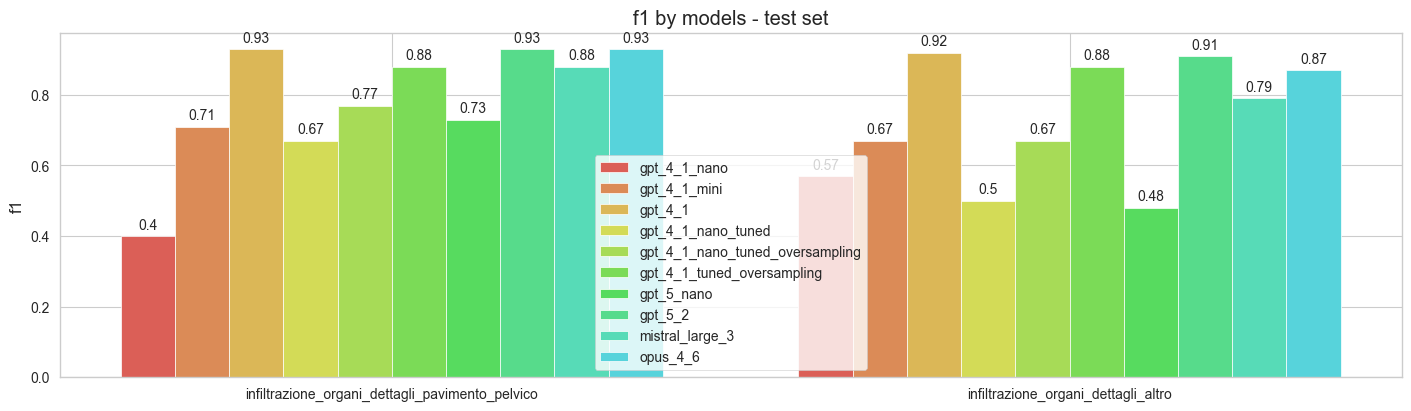

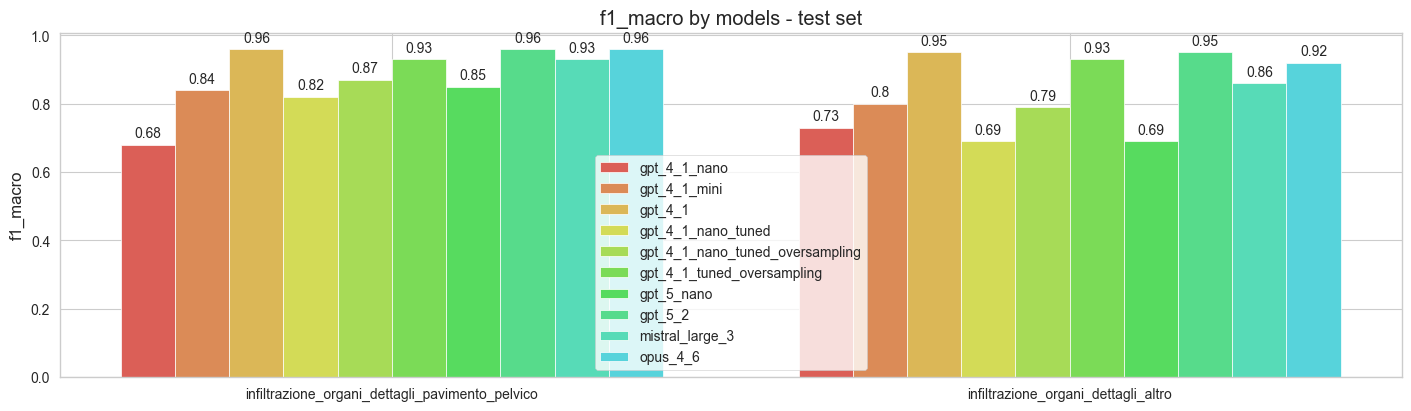

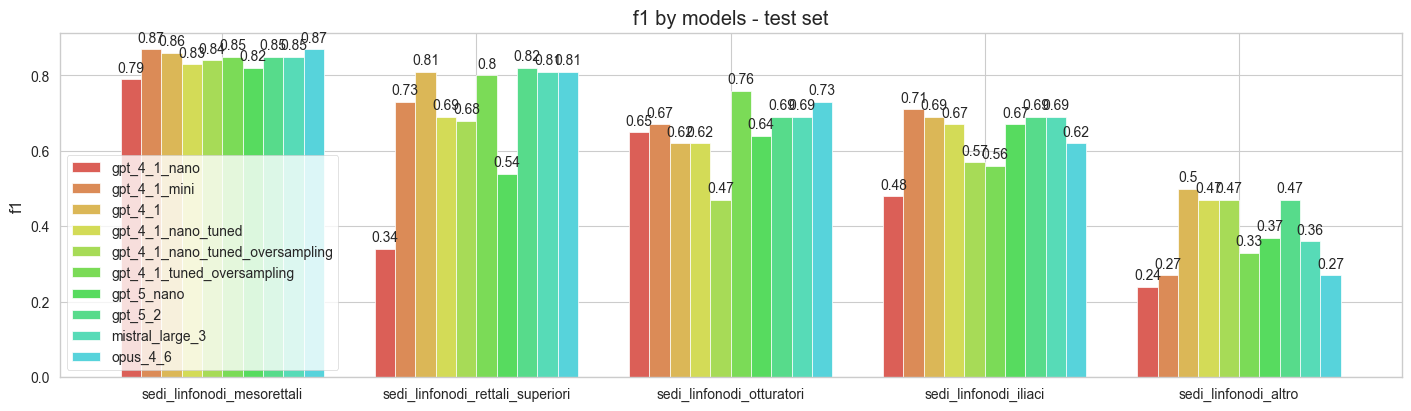

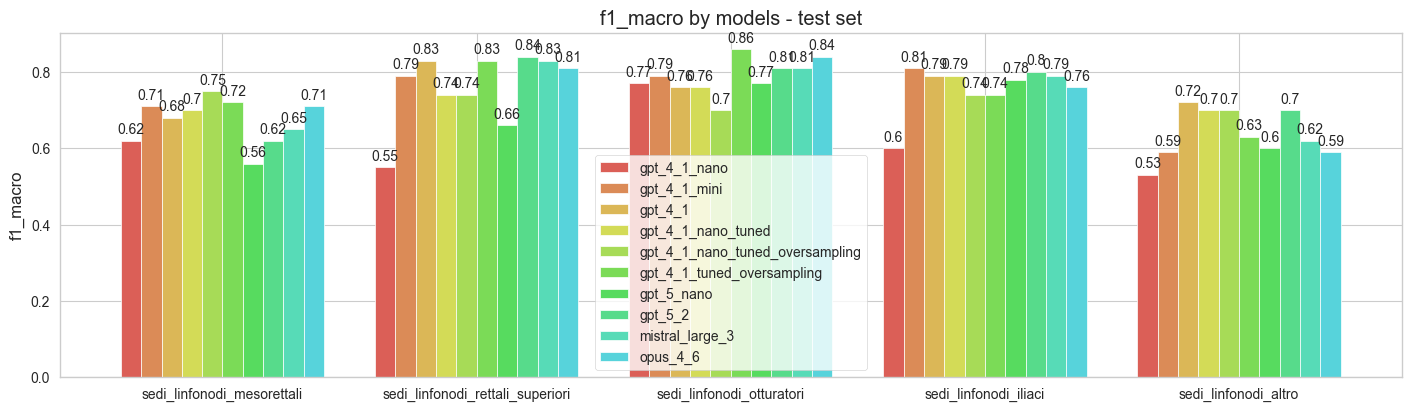

In [12]:
plot_fields = mc_fields_estesi[:4]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

plot_fields = mc_fields_estesi[4:6]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

plot_fields = mc_fields_estesi[6:]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

## Regression fields

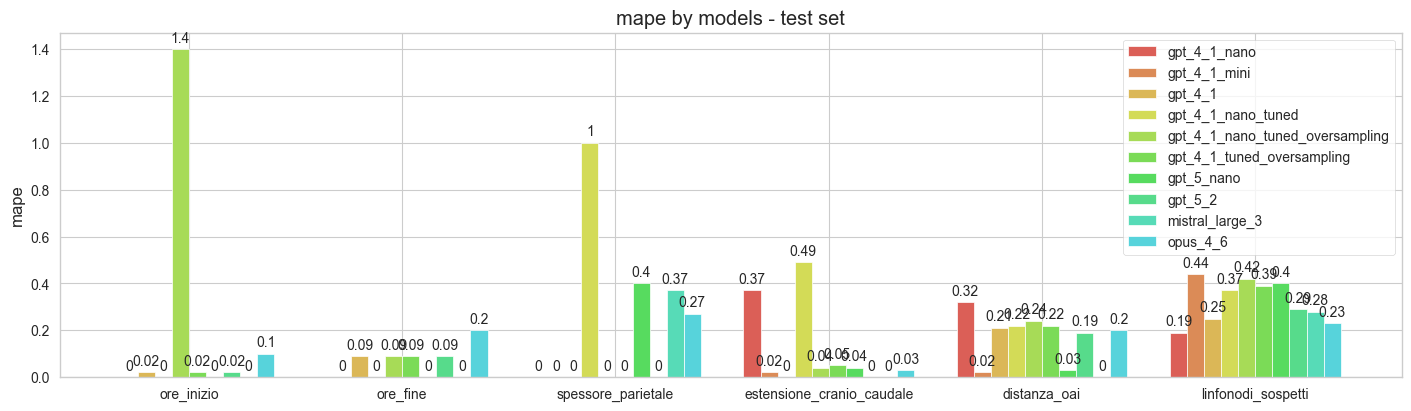

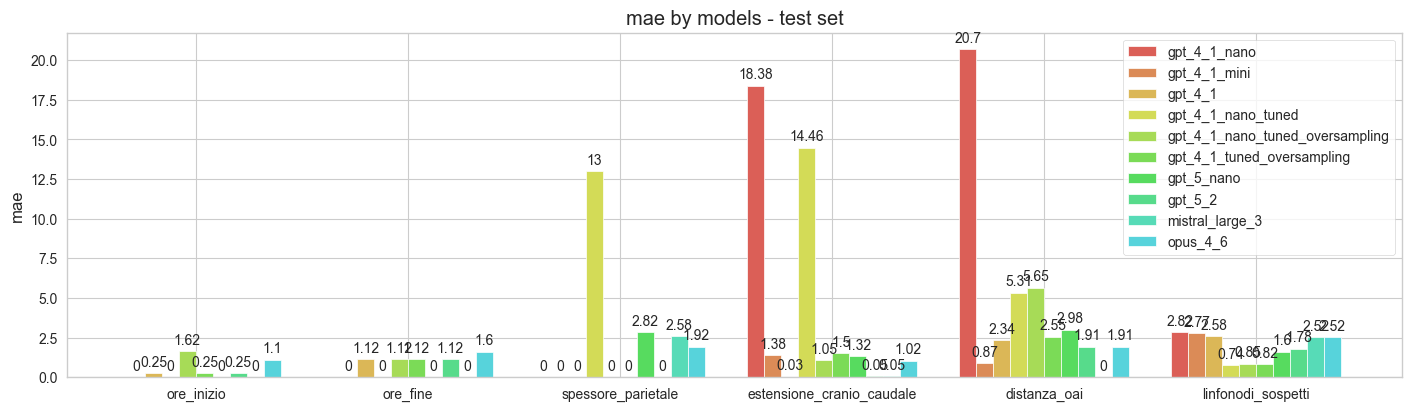

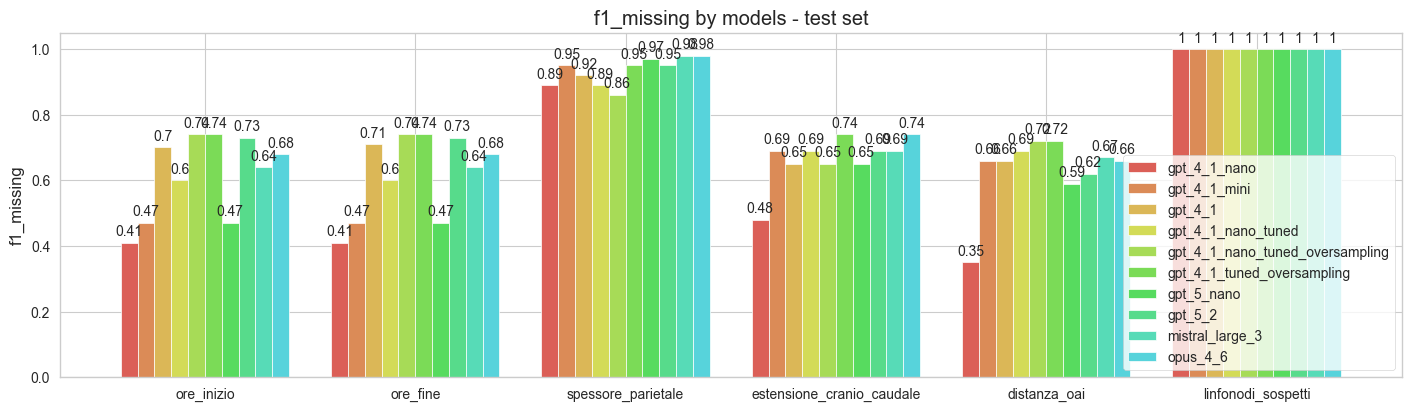

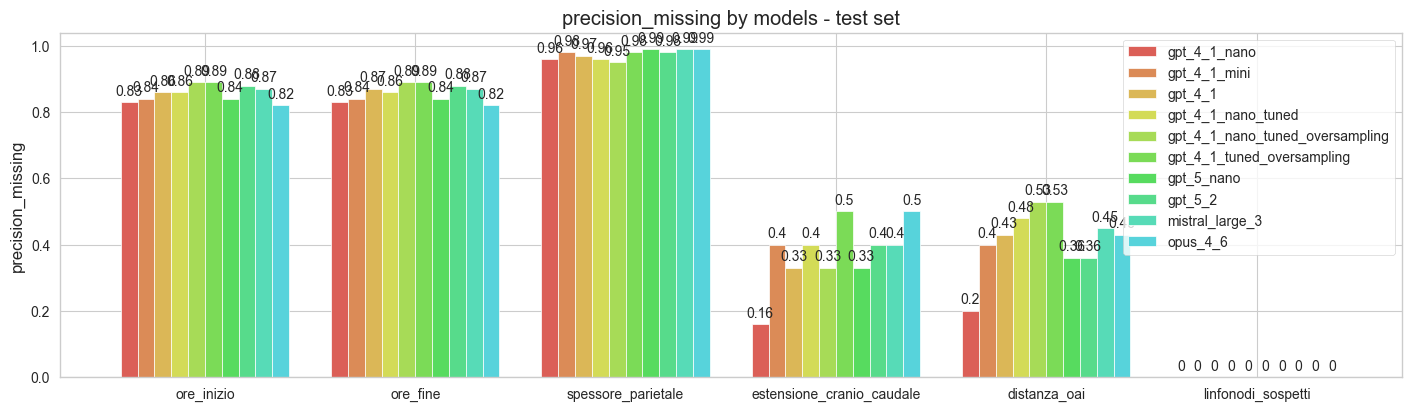

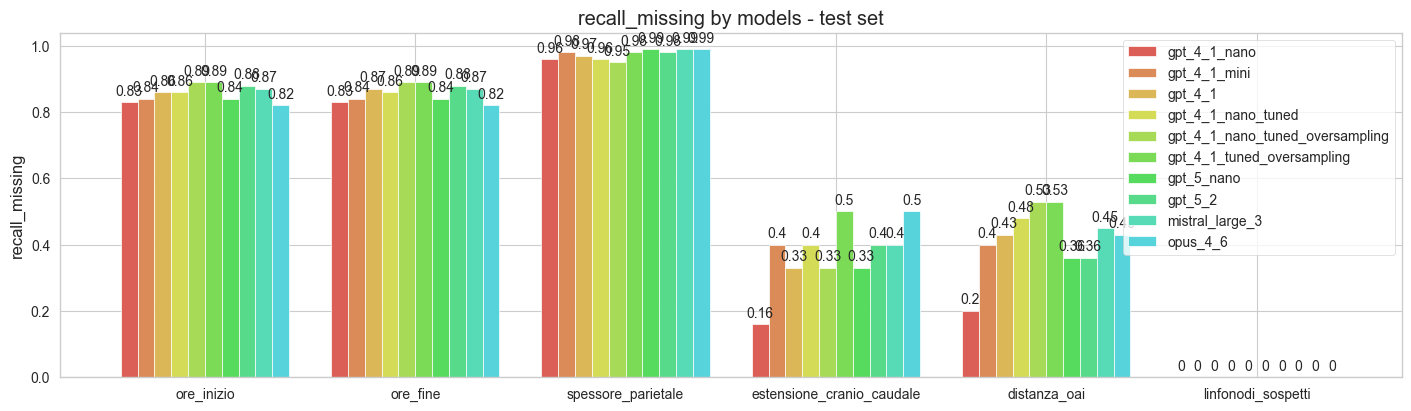

In [13]:
plot_models = [
    #'mean',
    'gpt_4_1_nano',
    'gpt_4_1_mini',
    'gpt_4_1',
    'gpt_4_1_nano_tuned',
    'gpt_4_1_nano_tuned_oversampling',
    'gpt_4_1_tuned_oversampling',
    'gpt_5_nano',
    'gpt_5_2',
    'mistral_large_3',
    'opus_4_6'
]
plot_fieds = reg_fields

plot_grouped_barchart(plot_fieds, plot_models, metric='mape')
plot_grouped_barchart(plot_fieds, plot_models, metric='mae')
plot_grouped_barchart(plot_fieds, plot_models, metric='f1_missing')
plot_grouped_barchart(plot_fieds, plot_models, metric='precision_missing')
plot_grouped_barchart(plot_fieds, plot_models, metric='recall_missing')